In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from collections import Counter
import math
from tqdm import tqdm

In [2]:
language="hindi"

corpus_file = f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{language}_processed.txt"

In [3]:
def load_and_tokenize_corpus(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        print(f"Loaded {len(words):,} words, {len(set(words)):,} unique words")
        return words
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return []
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return []


In [4]:

def calculate_word_frequencies(words):
    word_counts = Counter(words)
    sorted_words = word_counts.most_common()
    frequencies = [count for _, count in sorted_words]
    ranks = list(range(1, len(frequencies) + 1))
    return frequencies, ranks, dict(sorted_words)


In [5]:

def zipf_law(rank, alpha, C):
    return C / (rank ** alpha)

def mandelbrot_law(rank, alpha, beta, C):
    return C / ((rank + beta) ** alpha)


In [6]:
def fit_models(ranks, frequencies):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    results = {}
    
    # Zipf's law fitting - use nonlinear least squares like Mandelbrot
    try:
        def zipf_wrapper(rank, alpha, C):
            return zipf_law(rank, alpha, C)
        
        initial_guess = [1.0,frequencies[0]]
        params, _ = curve_fit(zipf_wrapper, ranks_np, freqs_np, p0=initial_guess, maxfev=5000)
        alpha_zipf, c_zipf = params
        
        zipf_pred = zipf_law(ranks_np, alpha_zipf, c_zipf)
        zipf_r2 = r2_score(freqs_np, zipf_pred)
        zipf_rmse = np.sqrt(mean_squared_error(freqs_np, zipf_pred))
        
        results['zipf'] = {
            'alpha': alpha_zipf,
            'C': c_zipf,
            'r2': zipf_r2,
            'rmse': zipf_rmse,
            'predictions': zipf_pred
        }
        
    except Exception as e:
        print(f"Error fitting Zipf's law: {e}")
        results['zipf'] = None
    
    # Mandelbrot's law fitting (unchanged)
    try:
        def mandelbrot_wrapper(rank, alpha, beta, C):
            return mandelbrot_law(rank, alpha, beta, C)
        
        initial_guess = [1.0, 2.0, frequencies[0]]
        params, _ = curve_fit(mandelbrot_wrapper, ranks_np, freqs_np, 
                             p0=initial_guess, maxfev=5000)
        alpha_mandel, beta_mandel , c_mandel= params
        
        mandel_pred = mandelbrot_law(ranks_np, alpha_mandel, beta_mandel, c_mandel)
        mandel_r2 = r2_score(freqs_np, mandel_pred)
        mandel_rmse = np.sqrt(mean_squared_error(freqs_np, mandel_pred))
        
        results['mandelbrot'] = {
            'alpha': alpha_mandel,
            'beta': beta_mandel,
            'C': c_mandel,
            'r2': mandel_r2,
            'rmse': mandel_rmse,
            'predictions': mandel_pred
        }
    except Exception as e:
        print(f"Error fitting Mandelbrot's law: {e}")
        results['mandelbrot'] = None
    
    return results

In [7]:

def analyze_top_words(word_freq_dict, top_percent=5):
    total_words = len(word_freq_dict)
    num_top_words = math.ceil(total_words * top_percent / 100)
    top_words = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)[:num_top_words]
    
    df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
    df['Rank'] = range(1, len(df) + 1)
    df['Percentage'] = (df['Frequency'] / df['Frequency'].sum()) * 100
    df['Cumulative_Percentage'] = df['Percentage'].cumsum()
    
    return df


In [8]:
def plot_law_analysis(ranks, frequencies, model_results):
    plt.figure(figsize=(12, 8))
    
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    
    plt.loglog(ranks_np, freqs_np, 'o', markersize=3, alpha=0.6, label='Actual Data')
    
    if model_results['zipf']:
        zipf_pred = model_results['zipf']['predictions']
        plt.loglog(ranks_np, zipf_pred, 'r--', linewidth=2, 
                  label=f'Zipf (α={model_results["zipf"]["alpha"]:.3f}, R²={model_results["zipf"]["r2"]:.3f})')
    
    if model_results['mandelbrot']:
        mandel_pred = model_results['mandelbrot']['predictions']
        plt.loglog(ranks_np, mandel_pred, 'g--', linewidth=2, 
                  label=f'Mandelbrot (α={model_results["mandelbrot"]["alpha"]:.3f}, β={model_results["mandelbrot"]["beta"]:.3f}, R²={model_results["mandelbrot"]["r2"]:.3f})')
    
    plt.xlabel('Rank (log scale)')
    plt.ylabel('Frequency (log scale)')
    plt.title('Zipf\'s Law and Mandelbrot Model Comparison\nRank-Frequency Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [9]:

def identify_deviation_points(ranks, frequencies, model_results):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    deviations = {}
    
    if model_results['zipf']:
        zipf_rel_error = np.abs((freqs_np - model_results['zipf']['predictions']) / freqs_np)
        max_zipf_dev = np.argmax(zipf_rel_error)
        deviations['zipf'] = {
            'max_deviation_rank': ranks_np[max_zipf_dev],
            'max_deviation_error': zipf_rel_error[max_zipf_dev]
        }
    
    if model_results['mandelbrot']:
        mandel_rel_error = np.abs((freqs_np - model_results['mandelbrot']['predictions']) / freqs_np)
        max_mandel_dev = np.argmax(mandel_rel_error)
        deviations['mandelbrot'] = {
            'max_deviation_rank': ranks_np[max_mandel_dev],
            'max_deviation_error': mandel_rel_error[max_mandel_dev]
        }
    
    return deviations


In [10]:
def print_prdiction_data(model_results):
    
    print("\nMODEL PARAMETERS AND FIT QUALITY:")
    print("=" * 50)
    
    comparison_data = []
    if model_results['zipf']:
        comparison_data.append([
            "Zipf's Law", 
            model_results['zipf']['alpha'], 
            "N/A", 
            model_results['zipf']['r2'], 
            model_results['zipf']['rmse']
        ])
    
    if model_results['mandelbrot']:
        comparison_data.append([
            "Mandelbrot's Law", 
            model_results['mandelbrot']['alpha'], 
            model_results['mandelbrot']['beta'], 
            model_results['mandelbrot']['r2'], 
            model_results['mandelbrot']['rmse']
        ])
    
    comparison_df = pd.DataFrame(comparison_data, 
                                columns=['Model', 'Alpha (α)', 'Beta (β)', 'R²', 'RMSE'])
    print(comparison_df.to_string(index=False))
    
    if model_results['zipf'] and model_results['mandelbrot']:
        if model_results['mandelbrot']['r2'] > model_results['zipf']['r2']:
            print("\n Mandelbrot's law provides a better fit (higher R²)")
        else:
            print("\n Zipf's law provides a better fit (higher R²)")

In [11]:
def print_frequent_words(top_words_df):
    print(f"\nTOP 5% MOST FREQUENT WORDS ANALYSIS:")
    print("=" * 50)
    print(f"These {len(top_words_df)} words account for {top_words_df['Cumulative_Percentage'].iloc[-1]:.1f}% of all word occurrences")
    
    print(f"\nTop 15 words (likely stop words or function words):")
    print(top_words_df.head(15)[['Rank', 'Word', 'Frequency', 'Percentage']].to_string(index=False))

In [12]:
def print_deviation_analysis(deviations):
    print(f"\nMODEL DEVIATION ANALYSIS:")
    print("=" * 50)
    if 'zipf' in deviations:
        print(f"Zipf's law has maximum deviation at rank {deviations['zipf']['max_deviation_rank']}")
        print(f"  Relative error: {deviations['zipf']['max_deviation_error']:.3f}")
    
    if 'mandelbrot' in deviations:
        print(f"Mandelbrot's law has maximum deviation at rank {deviations['mandelbrot']['max_deviation_rank']}")
        print(f"  Relative error: {deviations['mandelbrot']['max_deviation_error']:.3f}")

In [13]:
def main_analysis(corpus_file_path):
    print("Starting Law Analysis")
    print("=" * 50)
    
    words = load_and_tokenize_corpus(corpus_file_path)
    if not words:
        return
    
    frequencies, ranks, word_freq_dict = calculate_word_frequencies(words)
    model_results = fit_models(ranks, frequencies)
    top_words_df = analyze_top_words(word_freq_dict, 5)
    deviations = identify_deviation_points(ranks, frequencies, model_results)
    
    plot_law_analysis(ranks, frequencies, model_results)
    
    print_prdiction_data(model_results)
    
    print_frequent_words(top_words_df)
    
    print_deviation_analysis(deviations)
    


Starting Law Analysis
Loaded 88,757,626 words, 868,332 unique words


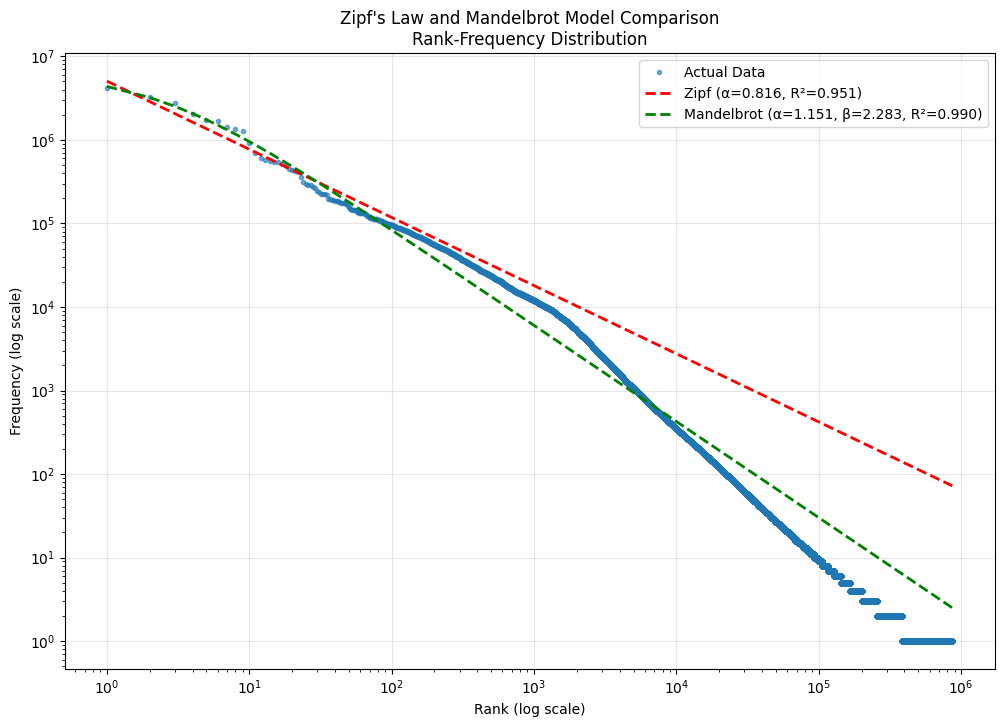


MODEL PARAMETERS AND FIT QUALITY:
           Model  Alpha (α)  Beta (β)       R²        RMSE
      Zipf's Law   0.815882       N/A 0.950636 1833.923488
Mandelbrot's Law   1.151098  2.283379 0.990279  813.804015

 Mandelbrot's law provides a better fit (higher R²)

TOP 5% MOST FREQUENT WORDS ANALYSIS:
These 43417 words account for 100.0% of all word occurrences

Top 15 words (likely stop words or function words):
 Rank Word  Frequency  Percentage
    1   के    4233590    4.905008
    2  में    3267043    3.785173
    3   है    2783150    3.224538
    4   की    2015420    2.335052
    5   और    1750781    2.028443
    6   से    1675469    1.941187
    7   को    1414909    1.639304
    8   का    1334363    1.545984
    9  हैं    1289459    1.493958
   10   एक     912468    1.057179
   11   पर     698613    0.809408
   12 किया     606926    0.703180
   13  रूप     580712    0.672809
   14  लिए     552257    0.639841
   15   ने     545328    0.631813

MODEL DEVIATION ANALYSIS:
Zipf's law h

In [14]:

main_analysis(corpus_file)